In [9]:
import seaborn as sns

In [2]:
import pandas as pd
df = pd.read_csv('mhd_rolling_results_all_feature_10year_1year.csv')
df.head()

,Unnamed: 0,Training_years,Testing year,Best Params,PR-AUC,Best threshold,F1-score_test,Precision_test,Recall_test,F1 Gap (Train-Test),Train_size,Test_size
0,0,1994_2003,[2004],"{'clf__class_weight': 'balanced', 'clf__max_de...",0.7862,0.831520,0.784254,0.920071,0.683377,-0.027078,235303,23605
1,1,1995_2004,[2005],"{'clf__class_weight': 'balanced', 'clf__max_de...",0.8266,0.518016,0.822086,0.855547,0.791144,-0.219402,237827,23699
2,2,1996_2005,[2006],"{'clf__class_weight': 'balanced', 'clf__max_de...",0.6094,0.860368,0.574685,0.893657,0.423519,0.134443,237034,23321
3,3,1997_2006,[2007],"{'clf__class_weight': 'balanced', 'clf__max_de...",0.6164,0.552282,0.700820,0.985591,0.543720,-0.065035,235829,24298
4,4,1998_2007,[2008],"{'clf__class_weight': 'balanced', 'clf__max_de...",0.7701,0.808837,0.845751,0.964187,0.753228,-0.316442,236125,24326


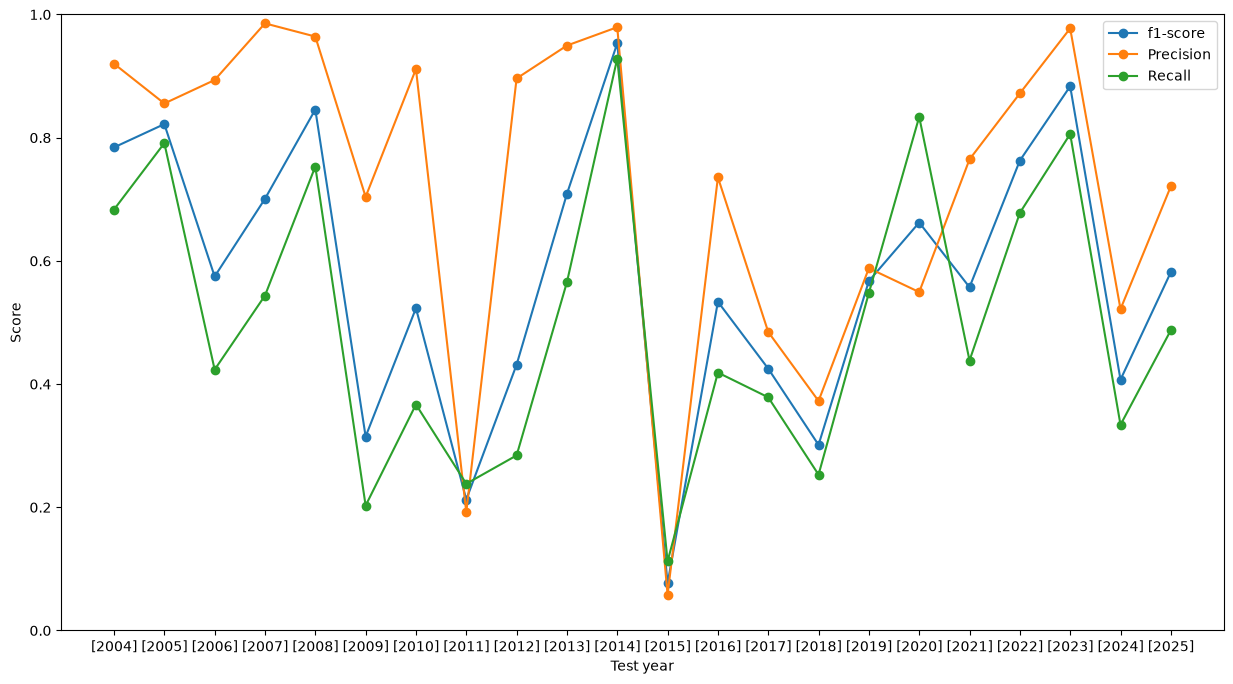

In [4]:
import matplotlib.pyplot as plt

plt.subplots(figsize=(15,8))
plt.plot(df['Testing year'], df['F1-score_test'], marker='o', label='f1-score')
plt.plot(df['Testing year'], df['Precision_test'], marker='o', label='Precision')
plt.plot(df['Testing year'], df['Recall_test'], marker='o', label='Recall')
plt.xlabel('Test year')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.legend()

plt.show()

# Feature Importance

## window = 10 years

In [21]:
df_feature = pd.read_csv('df_imp_mhd_5year_1year.csv', index_col=0)
df_feature.index.name = 'Feature'

df_feature.head()

,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,...,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
Feature,,,,,,,,,,,,,,,,,,,,,
pflow,0.000775,0.000779,0.002352,0.001812,0.000390,0.000687,0.001221,0.000402,0.000330,0.000434,...,0.001959,0.001782,0.000310,0.000615,0.002601,0.001299,0.000974,0.001354,0.000443,0.000390
tmod,0.000064,0.000081,0.000102,0.000145,0.000070,0.000010,0.000000,0.000003,0.000022,0.000006,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000004,0.000000
CH4_rt,0.002885,0.005082,0.006926,0.012963,0.010472,0.000988,0.001504,0.000484,0.001460,0.002913,...,0.002029,0.009003,0.001201,0.004278,0.013688,0.007829,0.006815,0.008248,0.005988,0.002803
CH4_w,0.004637,0.004131,0.004027,0.003378,0.004489,0.008451,0.019900,0.018824,0.011070,0.009411,...,0.021941,0.008571,0.007450,0.057238,0.024009,0.026957,0.044618,0.037389,0.068780,0.058048
CH4_ht,0.001801,0.001048,0.001546,0.002698,0.002473,0.003783,0.003931,0.002916,0.001128,0.000394,...,0.001366,0.001755,0.000478,0.001898,0.005772,0.004718,0.003749,0.003609,0.001663,0.001234


In [22]:

rank_df  = df_feature.rank(ascending=False, axis=0)

top10_counts =  (rank_df <=10).sum(axis=1).sort_values(ascending=False)

print("Top 10:",top10_counts)

Top 10: Feature
CH4_w_roll_std_2h_CH4_w_roll_mean_2h_ratio            21
CH4_w_residual_40min                                  21
CH4_w_roll_std_6h_CH4_w_roll_mean_6h_ratio            19
CH4_area_roll_std_2h_CH4_area_roll_mean_2h_ratio      17
CH4_w_residual_2h                                     15
                                                      ..
last_air_CH4_ht_log                                    0
CH4_ht_last_air_CH4_ht_diff_cross                      0
CH4_start_level_CH4_end_level_ratio                    0
CH4_w_CH4_end_time_CH4_start_time_diff_cross_ratio     0
last_std_CH4_ht_last_air_CH4_ht_ratio                  0
Length: 90, dtype: int64


Text(0.5, 1.0, 'Heatmap of Training Feature Importances Across Rolling Windows=10')

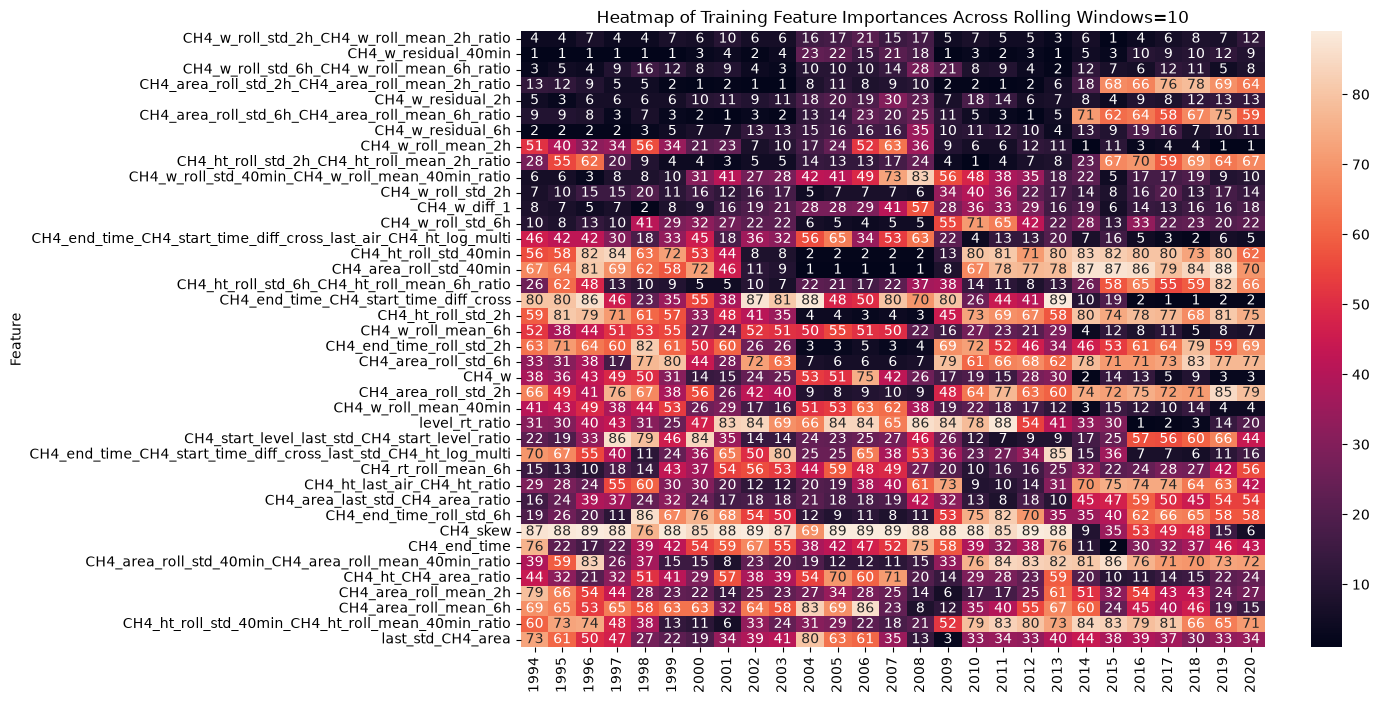

In [23]:
plot_features = top10_counts[top10_counts>0].index
plt.figure(figsize=(12,8))
sns.heatmap(
    rank_df.loc[plot_features],
    annot=True,
)
plt.title('Heatmap of Training Feature Importances Across Rolling Windows=10')

## 5 years

# f1-score, ROC curve

In [13]:
df_feature = pd.read_csv('mhd_rolling_results_all_feature_5year_1year.csv', index_col=0)
df_feature.index.name = 'Feature'

df_feature.head()

,Training_years,Testing year,Best Params,PR-AUC,Best threshold,F1-score_test,Precision_test,Recall_test,F1 Gap (Train-Test),Train_size,Test_size
Feature,,,,,,,,,,,
0,1994_1998,[1999],"{'clf__class_weight': 'balanced', 'clf__max_de...",0.6670,0.787350,0.645394,0.706658,0.593906,0.166913,116539,23420
1,1995_1999,[2000],"{'clf__class_weight': 'balanced', 'clf__max_de...",0.5473,0.808174,0.538534,0.557655,0.520681,0.330663,118878,23842
2,1996_2000,[2001],"{'clf__class_weight': 'balanced', 'clf__max_de...",0.4569,0.399929,0.463394,0.330270,0.776307,0.350769,118228,23983
3,1997_2001,[2002],"{'clf__class_weight': 'balanced', 'clf__max_de...",0.7251,0.680184,0.750161,0.894334,0.646018,-0.012544,117685,23619
4,1998_2002,[2003],"{'clf__class_weight': 'balanced', 'clf__max_de...",0.6597,0.598302,0.610957,0.661871,0.567318,0.006871,117302,23900


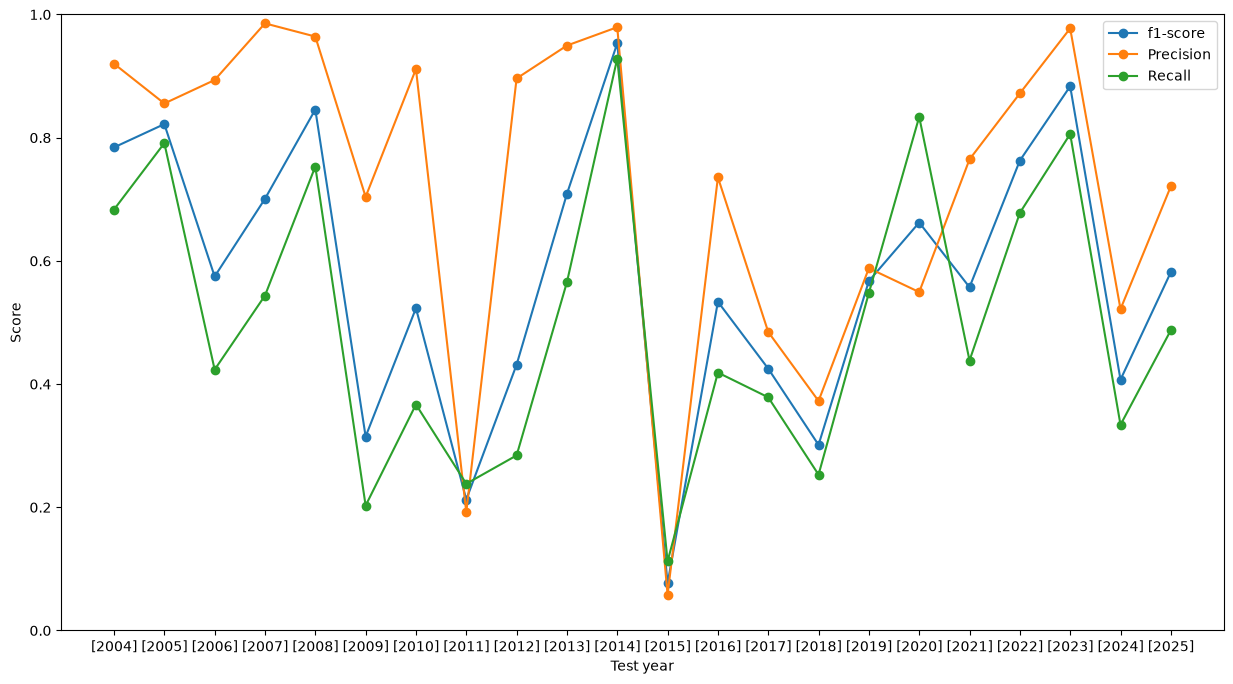

In [14]:
import matplotlib.pyplot as plt

plt.subplots(figsize=(15,8))
plt.plot(df['Testing year'], df['F1-score_test'], marker='o', label='f1-score')
plt.plot(df['Testing year'], df['Precision_test'], marker='o', label='Precision')
plt.plot(df['Testing year'], df['Recall_test'], marker='o', label='Recall')
plt.xlabel('Test year')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.legend()

plt.show()

In [15]:
df_feature = pd.read_csv('df_imp_mhd_5year_1year.csv', index_col=0)
df_feature.index.name = 'Feature'

df_feature.head()

,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,...,2011,2012,2013,2014,2015,2016,2017,2018,2019,2020
Feature,,,,,,,,,,,,,,,,,,,,,
pflow,0.000775,0.000779,0.002352,0.001812,0.000390,0.000687,0.001221,0.000402,0.000330,0.000434,...,0.001959,0.001782,0.000310,0.000615,0.002601,0.001299,0.000974,0.001354,0.000443,0.000390
tmod,0.000064,0.000081,0.000102,0.000145,0.000070,0.000010,0.000000,0.000003,0.000022,0.000006,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000004,0.000000
CH4_rt,0.002885,0.005082,0.006926,0.012963,0.010472,0.000988,0.001504,0.000484,0.001460,0.002913,...,0.002029,0.009003,0.001201,0.004278,0.013688,0.007829,0.006815,0.008248,0.005988,0.002803
CH4_w,0.004637,0.004131,0.004027,0.003378,0.004489,0.008451,0.019900,0.018824,0.011070,0.009411,...,0.021941,0.008571,0.007450,0.057238,0.024009,0.026957,0.044618,0.037389,0.068780,0.058048
CH4_ht,0.001801,0.001048,0.001546,0.002698,0.002473,0.003783,0.003931,0.002916,0.001128,0.000394,...,0.001366,0.001755,0.000478,0.001898,0.005772,0.004718,0.003749,0.003609,0.001663,0.001234


In [16]:
rank_df  = df_feature.rank(ascending=False, axis=0)

top10_counts =  (rank_df <=10).sum(axis=1).sort_values(ascending=False)

print("Top 10:",top10_counts)

Top 10: Feature
CH4_w_roll_std_2h_CH4_w_roll_mean_2h_ratio            21
CH4_w_residual_40min                                  21
CH4_w_roll_std_6h_CH4_w_roll_mean_6h_ratio            19
CH4_area_roll_std_2h_CH4_area_roll_mean_2h_ratio      17
CH4_w_residual_2h                                     15
                                                      ..
last_air_CH4_ht_log                                    0
CH4_ht_last_air_CH4_ht_diff_cross                      0
CH4_start_level_CH4_end_level_ratio                    0
CH4_w_CH4_end_time_CH4_start_time_diff_cross_ratio     0
last_std_CH4_ht_last_air_CH4_ht_ratio                  0
Length: 90, dtype: int64


Text(0.5, 1.0, 'Heatmap of Training Feature Importances Across Rolling Windows=10')

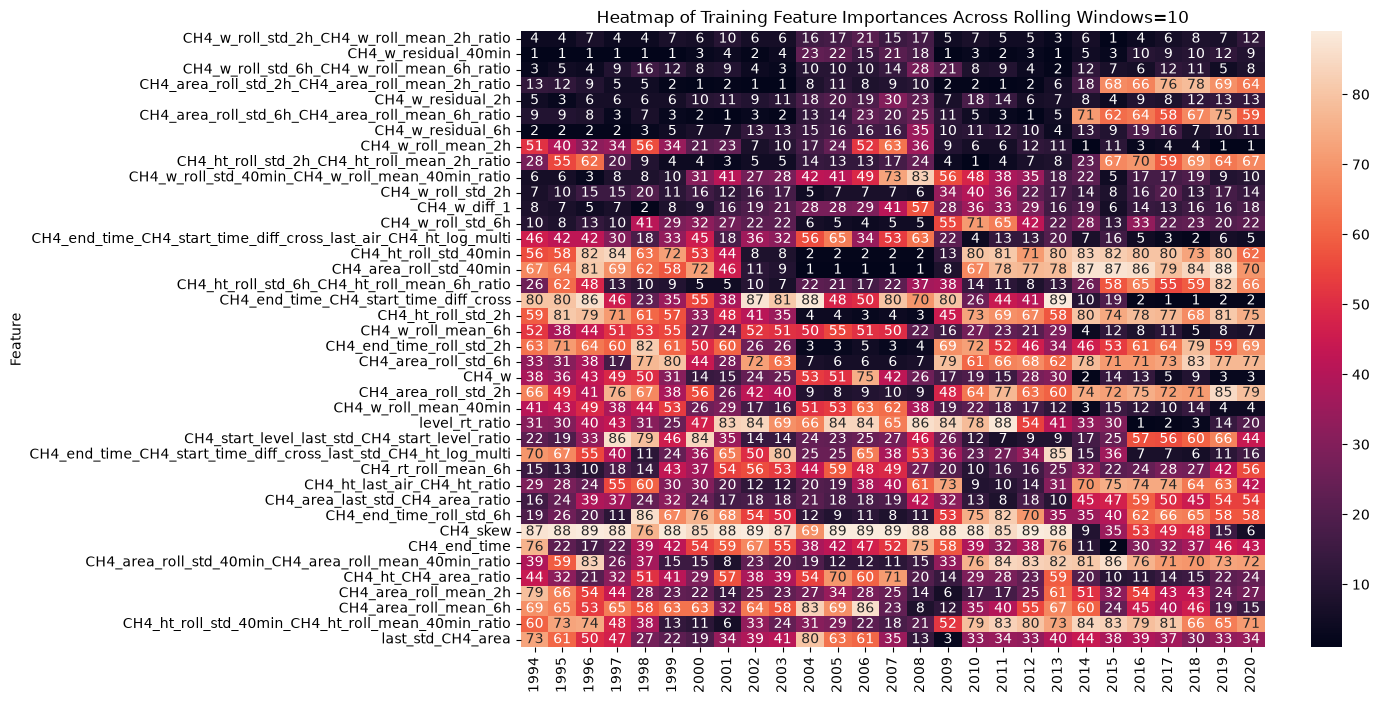

In [17]:
plot_features = top10_counts[top10_counts>0].index
plt.figure(figsize=(12,8))
sns.heatmap(
    rank_df.loc[plot_features],
    annot=True,
)
plt.title('Heatmap of Training Feature Importances Across Rolling Windows=10')

## 3 year

In [24]:
df_feature = pd.read_csv('mhd_rolling_results_all_feature_3year_1year.csv', index_col=0)
df_feature.index.name = 'Feature'

df_feature.head()

,Training_years,Testing year,Best Params,PR-AUC,Best threshold,F1-score_test,Precision_test,Recall_test,F1 Gap (Train-Test),Train_size,Test_size
Feature,,,,,,,,,,,
0,1994_1996,[1997],"{'clf__class_weight': 'balanced', 'clf__max_de...",0.7794,0.580603,0.733661,0.780736,0.691941,-0.085189,70099,24002
1,1995_1997,[1998],"{'clf__class_weight': 'balanced', 'clf__max_de...",0.4875,0.872376,0.499407,0.562333,0.449147,0.432374,73020,22438
2,1996_1998,[1999],"{'clf__class_weight': 'balanced', 'clf__max_de...",0.6673,0.798104,0.650157,0.748736,0.574515,0.171334,70966,23420
3,1997_1999,[2000],"{'clf__class_weight': 'balanced', 'clf__max_de...",0.5434,0.802729,0.542014,0.573270,0.513990,0.380030,69860,23842
4,1998_2000,[2001],"{'clf__class_weight': 'balanced', 'clf__max_de...",0.3594,0.516193,0.394208,0.597734,0.294077,0.247228,69700,23983


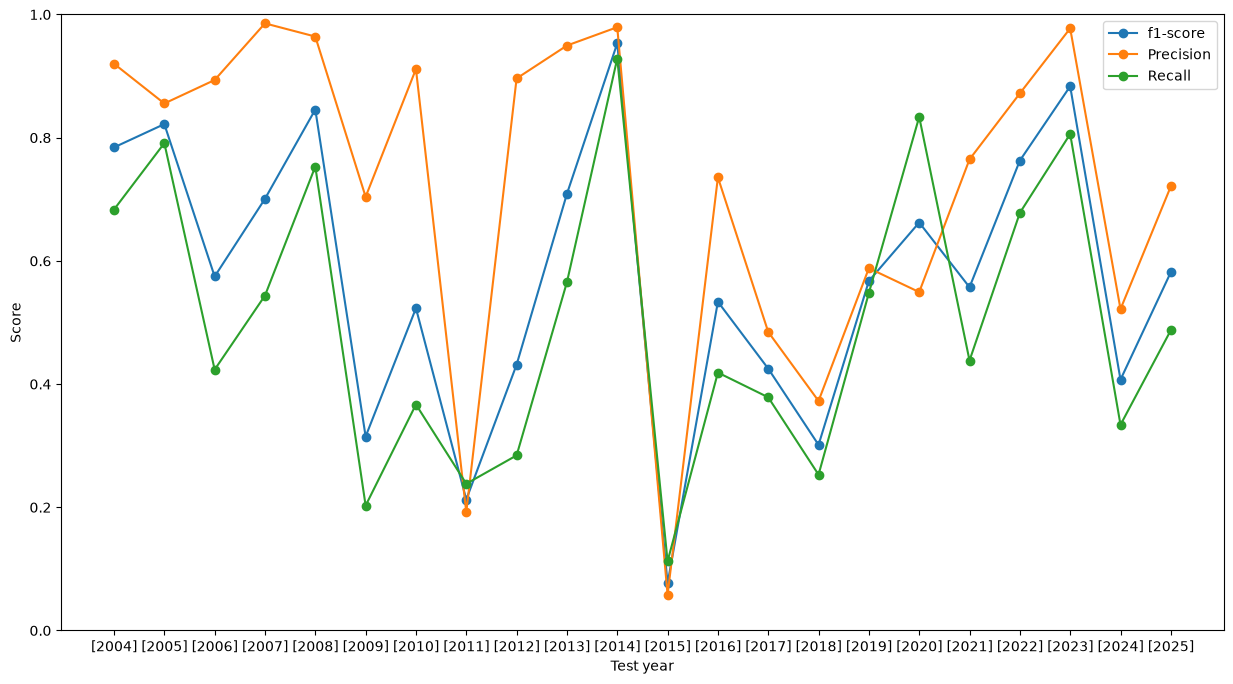

In [25]:
import matplotlib.pyplot as plt

plt.subplots(figsize=(15,8))
plt.plot(df['Testing year'], df['F1-score_test'], marker='o', label='f1-score')
plt.plot(df['Testing year'], df['Precision_test'], marker='o', label='Precision')
plt.plot(df['Testing year'], df['Recall_test'], marker='o', label='Recall')
plt.xlabel('Test year')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.legend()

plt.show()

In [26]:
df_feature = pd.read_csv('df_imp_mhd_3year_1year.csv', index_col=0)
df_feature.index.name = 'Feature'

df_feature.head()

,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,...,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022
Feature,,,,,,,,,,,,,,,,,,,,,
pflow,0.002171,0.000738,0.001110,0.001626,0.001315,0.000967,0.000972,5.710535e-04,0.001310,1.569447e-03,...,0.000221,0.000258,0.000832,0.001346,0.002218,0.001362,0.001208,0.001058,0.001973,0.000774
tmod,0.000018,0.000028,0.000056,0.000283,0.000210,0.000000,0.000000,5.481017e-10,0.000201,1.190556e-09,...,0.000000,0.000027,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
CH4_rt,0.000438,0.004327,0.003036,0.011182,0.012051,0.001741,0.000509,1.697578e-03,0.002194,9.454928e-04,...,0.009851,0.009728,0.004277,0.008444,0.013321,0.015398,0.004238,0.002855,0.008007,0.001046
CH4_w,0.004344,0.004255,0.006125,0.006086,0.011329,0.004621,0.013128,2.283229e-02,0.021766,9.472137e-03,...,0.000326,0.001259,0.010297,0.038832,0.022899,0.038748,0.058426,0.049595,0.022509,0.037038
CH4_ht,0.004144,0.023206,0.001330,0.000624,0.001750,0.008357,0.007118,5.129554e-03,0.002670,1.069320e-03,...,0.000192,0.000203,0.001690,0.003797,0.004102,0.006668,0.001433,0.001105,0.000623,0.000706


In [27]:
rank_df  = df_feature.rank(ascending=False, axis=0)

top10_counts =  (rank_df <=10).sum(axis=1).sort_values(ascending=False)

print("Top 10:",top10_counts)

Top 10: Feature
CH4_w_roll_std_2h_CH4_w_roll_mean_2h_ratio            20
CH4_w_residual_40min                                  19
CH4_w_roll_std_6h_CH4_w_roll_mean_6h_ratio            17
CH4_w_residual_2h                                     16
CH4_w_residual_6h                                     16
                                                      ..
last_std_CH4_ht_last_air_CH4_ht_diff_cross             0
CH4_area_residual_2h                                   0
CH4_start_level_CH4_end_level_ratio                    0
CH4_w_CH4_end_time_CH4_start_time_diff_cross_ratio     0
last_std_CH4_ht_last_air_CH4_ht_ratio                  0
Length: 90, dtype: int64


Text(0.5, 1.0, 'Heatmap of Training Feature Importances Across Rolling Windows=10')

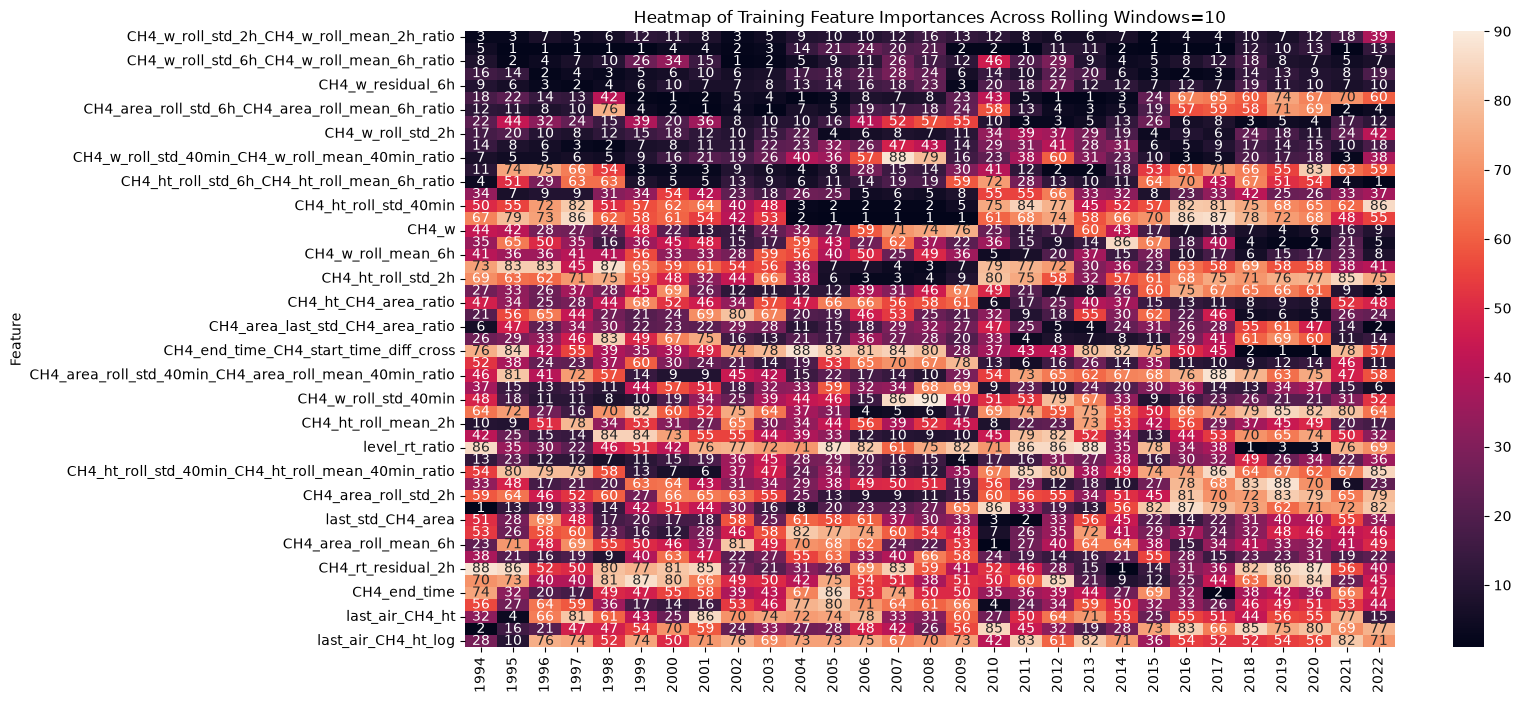

In [29]:
plot_features = top10_counts[top10_counts>0].index
plt.figure(figsize=(15,8))
sns.heatmap(
    rank_df.loc[plot_features],
    annot=True,
)
plt.title('Heatmap of Training Feature Importances Across Rolling Windows=10')

## 1 year

In [30]:
df_feature = pd.read_csv('mhd_rolling_results_all_feature_1year_1year.csv', index_col=0)
df_feature.index.name = 'Feature'

df_feature.head()

,Training_years,Testing year,Best Params,PR-AUC,Best threshold,F1-score_test,Precision_test,Recall_test,F1 Gap (Train-Test),Train_size,Test_size
Feature,,,,,,,,,,,
0,1994_1994,[1995],"{'clf__class_weight': 'balanced', 'clf__max_de...",0.5225,0.540591,0.546339,0.653215,0.469518,0.247056,21081,24492
1,1995_1995,[1996],"{'clf__class_weight': 'balanced', 'clf__max_de...",0.5345,0.607929,0.512945,0.648936,0.424076,0.142338,24492,24526
2,1996_1996,[1997],"{'clf__class_weight': 'balanced', 'clf__max_de...",0.7446,0.580626,0.712384,0.774354,0.659597,-0.018705,24526,24002
3,1997_1997,[1998],"{'clf__class_weight': 'balanced', 'clf__max_de...",0.4025,0.909155,0.407483,0.568428,0.317568,0.594754,24002,22438
4,1998_1998,[1999],"{'clf__class_weight': 'balanced', 'clf__max_de...",0.6583,0.770219,0.649536,0.736140,0.581163,0.163535,22438,23420


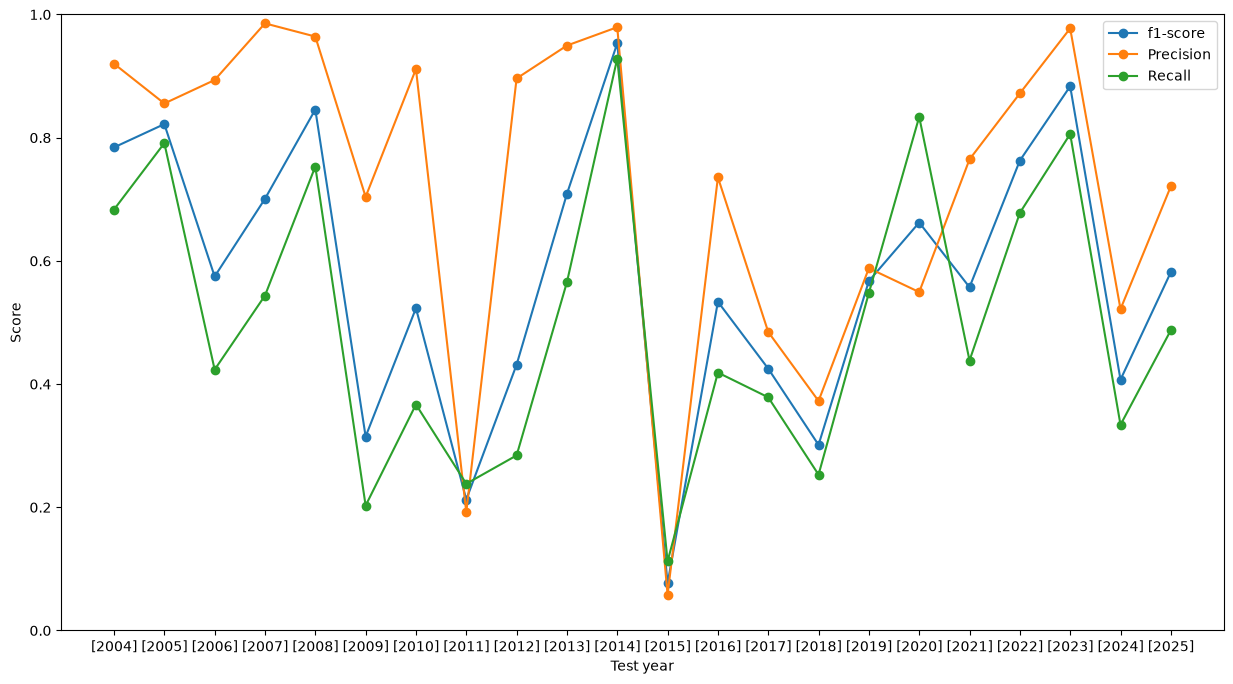

In [31]:
import matplotlib.pyplot as plt

plt.subplots(figsize=(15,8))
plt.plot(df['Testing year'], df['F1-score_test'], marker='o', label='f1-score')
plt.plot(df['Testing year'], df['Precision_test'], marker='o', label='Precision')
plt.plot(df['Testing year'], df['Recall_test'], marker='o', label='Recall')
plt.xlabel('Test year')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.legend()

plt.show()

In [32]:
df_feature = pd.read_csv('df_imp_mhd_1year_1year.csv', index_col=0)
df_feature.index.name = 'Feature'

df_feature.head()

,1994,1995,1996,1997,1998,1999,2000,2001,2002,2003,...,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
Feature,,,,,,,,,,,,,,,,,,,,,
pflow,0.001452,0.015244,0.001341,0.001209,0.001922,0.001481,0.003631,0.001767,0.001741,0.007194,...,0.008324,0.002486,0.002409,0.004366,0.002730,0.001389,0.011348,0.001299,0.000431,0.008419
tmod,0.000036,0.000124,0.000035,0.002374,0.000040,0.000000,0.000000,0.000005,0.000190,0.000000,...,0.000183,0.000027,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000262
CH4_rt,0.000562,0.000615,0.000887,0.007405,0.002419,0.000450,0.001094,0.000786,0.000689,0.002428,...,0.006912,0.002591,0.002532,0.010801,0.000660,0.014691,0.003166,0.000168,0.000801,0.004246
CH4_w,0.003449,0.006714,0.010652,0.007145,0.012095,0.011409,0.005681,0.008089,0.014306,0.030571,...,0.004252,0.008853,0.007109,0.049105,0.034185,0.026788,0.009614,0.011113,0.021411,0.009329
CH4_ht,0.010687,0.008304,0.006451,0.011006,0.001373,0.002430,0.007471,0.005866,0.003884,0.005639,...,0.003688,0.008090,0.004285,0.004893,0.002091,0.001641,0.005041,0.007033,0.000554,0.001985


In [33]:
rank_df  = df_feature.rank(ascending=False, axis=0)

top10_counts =  (rank_df <=10).sum(axis=1).sort_values(ascending=False)

print("Top 10:",top10_counts)

Top 10: Feature
CH4_w_residual_40min                          19
CH4_w_roll_std_2h_CH4_w_roll_mean_2h_ratio    18
CH4_w_residual_6h                             17
CH4_w_residual_2h                             16
CH4_w_roll_std_6h_CH4_w_roll_mean_6h_ratio    15
                                              ..
CH4_area_residual_6h                           0
CH4_area_residual_2h                           0
CH4_area_roll_mean_40min                       0
CH4_ht_last_air_CH4_ht_diff_cross              0
CH4_start_level_CH4_end_level_ratio            0
Length: 90, dtype: int64


Text(0.5, 1.0, 'Heatmap of Training Feature Importances Across Rolling Windows=1')

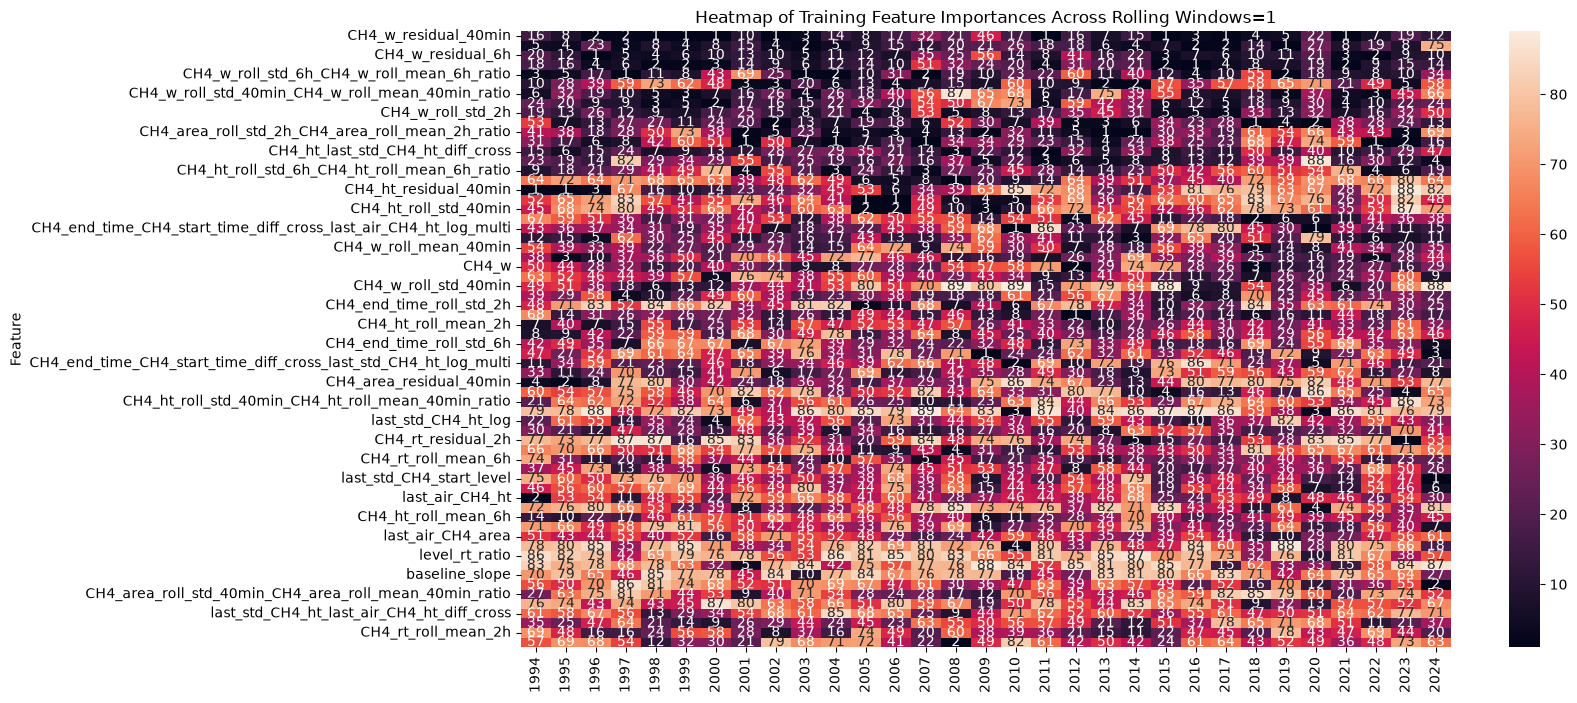

In [34]:
plot_features = top10_counts[top10_counts>0].index
plt.figure(figsize=(15,8))
sns.heatmap(
    rank_df.loc[plot_features],
    annot=True,
)
plt.title('Heatmap of Training Feature Importances Across Rolling Windows=1')